# PRT661 – Housing Affordability Forecasting System
## Assessment 2

**Group:** Dan1-Theme2 · **Theme 2 — Predictive Analytics and Forecasting**

**Pipeline order in this notebook:**

1. Load raw/processed data
2. Define a **reusable EDA toolkit** (functions, not one-off cells)
3. Run EDA on the data **as loaded** — surfaces exactly what needs cleaning, and why
4. Clean the data
5. Re-run the **same** EDA functions on the cleaned data — confirms what improved and what
   still needs a decision (outliers, suburb-matching gaps, temporal mismatch)
6. Feature engineering
7. Merge into a single model-ready dataset
8. Re-run EDA a third time, post-merge — checks correlation with the target and finalises the
   feature list actually going into the model
9. Temporal train/test split
10. Train and compare three models — **Linear Regression, Random Forest, XGBoost** — to predict
    actual sale price
11. Evaluate, compare, and export

Every EDA pass logs plain-English **insights** as it runs (`note(...)` calls) rather than just
drawing charts — the running list is printed in full at the end, so it reads as a decision log
you can paste straight into the Assessment 2 report.

## Project Setup — Imports & Directories

In [798]:
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 19
np.random.seed(RANDOM_STATE)


In [799]:
# Data directories
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_READY_DIR = DATA_DIR / "model_ready"
OUTPUT_DIR = DATA_DIR / "output"

for d in [RAW_DIR, PROCESSED_DIR, MODEL_READY_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PROPERTIES_PATH = RAW_DIR / "properties.csv"
ERP_PATH = RAW_DIR / "ERP.csv"
ANNUAL_HOUSEHOLD_PATH = RAW_DIR / "Annual_Household_NT.csv"

# Darwin CBD reference coordinates, used for the "distance from CBD" feature
DARWIN_CBD_LAT, DARWIN_CBD_LON = -12.4634, 130.8456



## 1. Loading Data
Loads `properties.csv`, **`ERP.csv`**, and **`Annual_Household_NT.csv`** and prints a quick
health check for each.

`ERP.csv` is the ABS Estimated Resident Population for the **Greater Darwin region as a whole**
(one row per year, 2006–2026) — it replaces the old `population.csv`, which was SA2-indexed and
required fragile suburb-to-SA2 name matching against the `properties` slugs. Since every property
in `properties` is located within Greater Darwin, ERP needs no suburb key at all: like
`Annual_Household_NT.csv`, it merges on **`year` alone**.


In [800]:
def load_csv(path, name):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find file at {path}.")
    df = pd.read_csv(path)
    print(f"Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df

properties_processed = load_csv(PROPERTIES_PATH, "Properties Dataset")
erp_raw = load_csv(ERP_PATH, "ERP Dataset (Greater Darwin Region)")
annual_household_raw = load_csv(ANNUAL_HOUSEHOLD_PATH, "Annual Household Income Dataset (NT)")



Loaded Properties Dataset: 15,423 rows x 18 columns
Loaded ERP Dataset (Greater Darwin Region): 21 rows x 2 columns
Loaded Annual Household Income Dataset (NT): 45 rows x 28 columns


In [801]:
def check_data(df, name):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(df.dtypes)
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing):
        print("\nMissing values:")
        print(missing)
    else:
        print("\nNo missing values.")
    display(df.head(2))

check_data(properties_processed, "Properties Dataset")
check_data(erp_raw, "ERP Dataset (Greater Darwin Region) — Number stored as text with thousands-separator commas")
check_data(annual_household_raw, "Annual Household Income Dataset (NT) — includes metadata rows to be cleaned")




Properties Dataset
property_id            int64
address                  str
url                      str
status                   str
sold_date                str
sold_date_iso            str
price_text               str
price_numeric        float64
price_undisclosed       bool
beds                   int64
baths                  int64
cars                   int64
land_area_m2             str
latitude             float64
longitude            float64
agent_name               str
agency_name              str
suburb                   str
dtype: object

Missing values:
agent_name       13273
agency_name      13273
land_area_m2      5800
price_text        5088
price_numeric     5088
sold_date          250
sold_date_iso      250
latitude           226
longitude          226
dtype: int64


,property_id,address,url,status,sold_date,sold_date_iso,price_text,price_numeric,price_undisclosed,beds,baths,cars,land_area_m2,latitude,longitude,agent_name,agency_name,suburb
0,11245030,"22 Caledonian Street, Anula NT 812",https://www.homely.com.au/homes/22-caledonian-...,Sold,15 Aug 2024,2024-08-15T00:00:00+00:00,"$540,000",540000.0,False,3,1,2,985m²,-12.393042,130.887771,Ella Carling,Real Estate Central,anula-nt-0812
1,11057061,"52 Wandie Crescent, Anula NT 812",https://www.homely.com.au/homes/52-wandie-cres...,Sold,4 Jul 2024,2024-07-04T00:00:00+00:00,"$560,000",560000.0,False,3,1,3,743m²,-12.394495,130.893049,Simon Watts,Real Estate Central,anula-nt-0812



ERP Dataset (Greater Darwin Region) — Number stored as text with thousands-separator commas
Year      int64
Number      str
dtype: object

No missing values.


,Year,Number
0,2006,"1,13,461"
1,2007,"1,16,935"



Annual Household Income Dataset (NT) — includes metadata rows to be cleaned
Unnamed: 0                                                                                 str
Gross operating surplus ;  Dwellings owned by persons ;                                    str
Gross mixed income ;                                                                       str
Compensation of employees ;                                                                str
Total property income receivable ;                                                         str
Total primary income receivable ;                                                          str
Secondary income receivable - Social benefits receivable - Workers' compensation ;         str
Secondary income receivable - Social benefits receivable - Social assistance benefits ;    str
Secondary income receivable - Current transfers to non-profit institutions ;               str
Other secondary income ;                                            

,Unnamed: 0,Gross operating surplus ; Dwellings owned by persons ;,Gross mixed income ;,Compensation of employees ;,Total property income receivable ;,Total primary income receivable ;,Secondary income receivable - Social benefits receivable - Workers' compensation ;,Secondary income receivable - Social benefits receivable - Social assistance benefits ;,Secondary income receivable - Current transfers to non-profit institutions ;,Other secondary income ;,Total secondary income receivable ;,TOTAL GROSS INCOME ;,Property income payable - Interest - Dwellings ;,Property income payable - Interest - Consumer debt ;,Property income payable - Unincorporated enterprises ;,Total property income payable ;,Total primary income payable ;,Secondary income payable - Income tax ;,Secondary income payable - Social contributions for workers' compensation ;,"Secondary income payable - Other current taxes on income, wealth, etc. ;",Other secondary income ;.1,Total secondary income payable ;,Total income payable ;,GROSS DISPOSABLE INCOME ;,Final consumption expenditure ;,Net saving plus consumption of fixed capital ;,Total gross income per capita ;,Gross household disposable income per capita ;
0,Unit,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$,$
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original


## 2. Reusable EDA Toolkit

These functions are defined **once** and called at three different points in the pipeline:
right after loading, again after cleaning, and again after merging. Calling the same function
on data before/after a transformation is what actually shows whether the transformation helped
— rather than eyeballing one-off charts that can't be compared.

Every function calls `note(stage, message)` whenever it detects something worth acting on. All
notes are collected in `INSIGHTS` and printed as a consolidated, prioritised list in the final
section — that list is the "so what do we do next" output of the whole EDA process.

In [802]:
INSIGHTS = []

def note(stage, message):
    """Logs an actionable insight. Printed immediately AND collected for the final summary."""
    INSIGHTS.append((stage, message))
    print(f"  \u2192 INSIGHT [{stage}]: {message}")


### 2.1 Missingness (any dataset, any stage)

In [803]:
def eda_missingness(datasets: dict, stage="RAW"):
    """datasets: {"name": dataframe, ...}"""
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes]
    for ax, (name, df) in zip(axes, datasets.items()):
        missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
        missing_pct = missing_pct[missing_pct > 0]
        if len(missing_pct) == 0:
            ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
            ax.set_title(f"{name} ({stage})")
            ax.axis("off")
            continue
        sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="#B00020")
        ax.set_title(f"{name} ({stage}) — % missing")
        ax.set_xlabel("% missing")
        for col, pct in missing_pct.items():
            if pct > 30:
                note(stage, f"'{col}' in {name} is {pct:.0f}% missing — decide: impute, drop column, or drop rows.")
            elif pct > 5:
                note(stage, f"'{col}' in {name} is {pct:.0f}% missing — plan and document an imputation strategy.")
    plt.tight_layout()
    plt.show()


### 2.2 Properties Profile (auto-detects parsing issues at RAW stage)

In [804]:
def eda_properties_profile(df, stage="RAW"):
    print(f"\n{'='*70}\nPROPERTIES — {stage}\n{'='*70}")
    d = df.copy()

    # --- Auto-detect common raw-data quirks so this function is safe to call on messy data ---
    if "suburb" in d.columns:
        looks_like_slug = d["suburb"].astype(str).str.contains("-").mean() > 0.5
        if looks_like_slug:
            note(stage, "suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a "
                         "clean name before joining with census/population data.")

    raw_land = d.get("land_area_m2")
    parsed_land = pd.to_numeric(raw_land, errors="coerce") if raw_land is not None else None
    if raw_land is not None:
        non_null_raw = raw_land.notna().sum()
        non_null_parsed = parsed_land.notna().sum() if parsed_land is not None else 0
        if non_null_raw > 0 and non_null_parsed / non_null_raw < 0.5:
            note(stage, "land_area_m2 looks like text with unit suffixes (e.g. '985m²') — "
                         "strip non-numeric characters before treating it as a number.")

    d["_price"] = pd.to_numeric(d.get("price_numeric"), errors="coerce")
    d["_land_area"] = parsed_land
    d["_sold_date"] = pd.to_datetime(d.get("sold_date_iso"), errors="coerce")
    d["_sale_year"] = d["_sold_date"].dt.year

    n_dupe = d.duplicated(subset=["property_id"]).sum() if "property_id" in d.columns else 0
    if n_dupe:
        note(stage, f"{n_dupe} duplicate property_id rows — deduplicate before modelling.")

    if "price_undisclosed" in d.columns and d["price_undisclosed"].dtype == object:
        note(stage, "price_undisclosed is stored as text ('true'/'false') — convert to 0/1 "
                     "before filtering on it.")

    print(f"Rows: {len(d):,} | Unique suburbs: {d['suburb'].nunique() if 'suburb' in d else 'n/a'} | "
          f"Sale years: {d['_sale_year'].min()}–{d['_sale_year'].max()}")

    # --- Plots (use coerced numeric columns so this works even on messy raw data) ---
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    if d["_price"].notna().sum() > 0:
        sns.histplot(d["_price"].dropna(), bins=50, ax=axes[0, 0], color="#2E5090")
    axes[0, 0].set_title("Sale Price Distribution")

    if d["_price"].notna().sum() > 0:
        sns.histplot(np.log1p(d["_price"].dropna()), bins=50, ax=axes[0, 1], color="#2E5090")
    axes[0, 1].set_title("Log(Sale Price) Distribution")

    sales_per_year = d["_sale_year"].value_counts().sort_index()
    axes[0, 2].bar(sales_per_year.index.astype(str), sales_per_year.values, color="#2E5090")
    axes[0, 2].set_title("Number of Sales per Year")
    axes[0, 2].tick_params(axis="x", rotation=45)

    if {"beds", "baths", "cars"}.issubset(d.columns):
        bbc = d[["beds", "baths", "cars"]].melt(var_name="type", value_name="count")
        sns.countplot(data=bbc, x="count", hue="type", ax=axes[1, 0])
    axes[1, 0].set_title("Beds / Baths / Cars Distribution")

    if "suburb" in d.columns:
        top_suburbs = d["suburb"].value_counts().head(15)
        sns.barplot(x=top_suburbs.values, y=top_suburbs.index, ax=axes[1, 1], color="#2E5090")
    axes[1, 1].set_title("Top 15 Suburbs by Listing Count")

    if {"latitude", "longitude"}.issubset(d.columns):
        valid_geo = d.dropna(subset=["latitude", "longitude", "_price"])
        sc = axes[1, 2].scatter(valid_geo["longitude"], valid_geo["latitude"], c=valid_geo["_price"],
                                 cmap="viridis", s=14, alpha=0.6)
        axes[1, 2].scatter([DARWIN_CBD_LON], [DARWIN_CBD_LAT], marker="*", s=250, color="red", label="Darwin CBD")
        axes[1, 2].legend()
        plt.colorbar(sc, ax=axes[1, 2], label="Price (AUD)")
    axes[1, 2].set_title("Geographic Spread — colour = price")

    plt.tight_layout()
    plt.show()

    # --- Outlier check (IQR) ---
    if d["_price"].notna().sum() > 10:
        q1, q3 = d["_price"].quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((d["_price"] < q1 - 1.5 * iqr) | (d["_price"] > q3 + 1.5 * iqr)).sum()
        pct_out = n_out / d["_price"].notna().sum() * 100
        print(f"IQR-based price outliers: {n_out} ({pct_out:.1f}%)")
        if pct_out > 5:
            note(stage, f"{n_out} price outliers ({pct_out:.1f}%) — decide whether to cap, "
                         f"remove, or keep with justification before training a linear model "
                         f"(tree models are less sensitive to this).")
    return d


### 2.3 Annual Household Income Profile (NT-Wide Time Series)

In [805]:
def eda_annual_household_profile(df, stage="RAW"):
    """df is expected to have a 'year' column plus numeric economic indicator columns.
    Unlike the old suburb-level census snapshot, this is a genuine multi-year series, so the
    checks here focus on time coverage and trend shape rather than suburb comparisons.

    Which indicators are "key" is NOT assumed up front -- at RAW stage we don't yet know that,
    and asserting it before looking would just be a guess dressed up as an insight. Instead this
    function derives it from the data: with ~two dozen raw NT income sub-accounts that all
    mechanically track the same underlying economy, it clusters columns by pairwise
    correlation and keeps one representative per cluster. Returns that derived list so later
    cells use exactly what THIS analysis found, not a pre-chosen guess."""
    print(f"\n{'='*70}\nANNUAL HOUSEHOLD INCOME (NT) — {stage}\n{'='*70}")

    if "year" not in df.columns:
        note(stage, "Annual household dataset has no parsed 'year' column yet — "
                     "parse the 'Jun-YYYY' style period labels before using this data. "
                     "(Which indicators matter can't be determined before that parsing anyway.)")
        return None

    year_min, year_max = int(df["year"].min()), int(df["year"].max())
    print(f"Year coverage: {year_min}–{year_max} ({df['year'].nunique()} years)")

    gap_years = sorted(set(range(year_min, year_max + 1)) - set(df["year"].unique()))
    if gap_years:
        note(stage, f"Annual household series has gap year(s): {gap_years} — "
                     f"sales in those years won't get a match on this dataset.")

    plt.figure(figsize=(30, 15))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title(f"Annual Household Income — Correlation ({stage})")
    plt.tight_layout()
    plt.show()

    note(stage, "This dataset is NT-WIDE, not suburb-level — every suburb receives the same "
                 "figure for a given year. This trades away suburb-level income granularity in "
                 "exchange for full 1990–2025 year coverage.")



### 2.4 ERP Profile (Greater Darwin Region, Year-Only Time Series)


In [806]:
def eda_erp_profile(df, stage="RAW"):
    """df is expected to have a year column and a population/number column, one row per year,
    for the Greater Darwin region as a whole. Unlike the old SA2-indexed population.csv, there
    is no suburb dimension here, so the checks focus on year coverage and trend shape (the same
    approach used for eda_annual_household_profile) rather than suburb comparisons."""
    print(f"\n{'='*70}\nERP — GREATER DARWIN REGION — {stage}\n{'='*70}")
    d = df.copy()

    year_col = "Year" if "Year" in d.columns else "year"
    pop_col = "Number" if "Number" in d.columns else "population"

    if d[pop_col].dtype == object:
        note(stage, f"'{pop_col}' in ERP is stored as text with thousands-separator commas "
                     f"(e.g. '1,63,219') — strip commas before treating it as numeric.")

    d["_year"] = pd.to_numeric(d[year_col], errors="coerce")
    d["_population"] = pd.to_numeric(
        d[pop_col].astype(str).str.replace(",", "", regex=False), errors="coerce"
    )
    d = d.dropna(subset=["_year"]).sort_values("_year")

    year_min, year_max = int(d["_year"].min()), int(d["_year"].max())
    print(f"Year coverage: {year_min}–{year_max} ({d['_year'].nunique()} years)")

    gap_years = sorted(set(range(year_min, year_max + 1)) - set(d["_year"].unique()))
    if gap_years:
        note(stage, f"ERP series has gap year(s): {gap_years} — "
                     f"sales in those years won't get a direct ERP match.")

    plt.figure(figsize=(10, 4))
    plt.plot(d["_year"], d["_population"], marker="o", color="#2E5090")
    plt.title(f"Greater Darwin Estimated Resident Population ({stage})")
    plt.xlabel("Year"); plt.ylabel("Population")
    plt.tight_layout(); plt.show()

    pct_change = d["_population"].pct_change() * 100
    big_swings = d.loc[pct_change.abs() > 15, "_year"].tolist()
    if big_swings:
        note(stage, f"Year(s) with >15% YoY change in Greater Darwin ERP: {big_swings} — "
                     f"worth sanity-checking against ABS boundary/methodology revisions.")

    return d



### 2.7 Orchestrator — runs every check above in one call

In [807]:
def run_full_eda(properties_df, annual_household_df, erp_df, stage="RAW"):
    """Runs the complete EDA toolkit at a given pipeline stage. Call this again after cleaning,
    and a third time after merging, to see exactly what changed.

    Returns (household_key_indicators, erp_clean) -- both DERIVED by this pass, not supplied to
    it. At RAW stage household_key_indicators is None (year isn't parsed yet, so nothing can be
    derived); at CLEANED stage it's the correlation-clustered list this pass actually found."""
    print(f"\n{'#'*70}\n# FULL EDA PASS — STAGE: {stage}\n{'#'*70}")
    eda_missingness(
        {"properties": properties_df, "annual_household": annual_household_df, "erp": erp_df},
        stage=stage
    )
    eda_properties_profile(properties_df, stage=stage)
    eda_annual_household_profile(annual_household_df, stage=stage)
    erp_clean = eda_erp_profile(erp_df, stage=stage)
    return erp_clean



## 2.8 Run EDA — Pass 1: Data As Loaded

This surfaces exactly what needs cleaning (and why) before a single cleaning line is written —
notice the automatically-detected warnings about the suburb slug, the text land-area column,
etc.


######################################################################
# FULL EDA PASS — STAGE: RAW
######################################################################
  → INSIGHT [RAW]: 'agency_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'agent_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'land_area_m2' in properties is 38% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'price_text' in properties is 33% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'price_numeric' in properties is 33% missing — decide: impute, drop column, or drop rows.


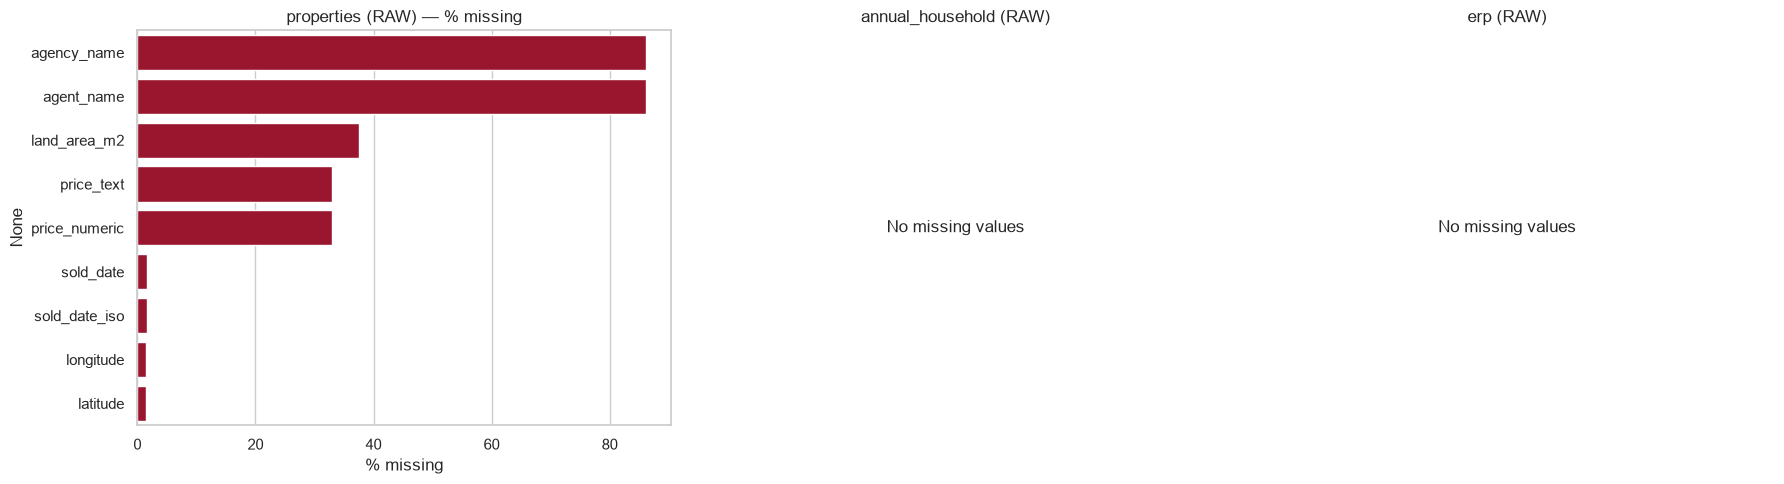


PROPERTIES — RAW
  → INSIGHT [RAW]: suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a clean name before joining with census/population data.
  → INSIGHT [RAW]: land_area_m2 looks like text with unit suffixes (e.g. '985m²') — strip non-numeric characters before treating it as a number.
Rows: 15,423 | Unique suburbs: 74 | Sale years: 1920.0–2026.0


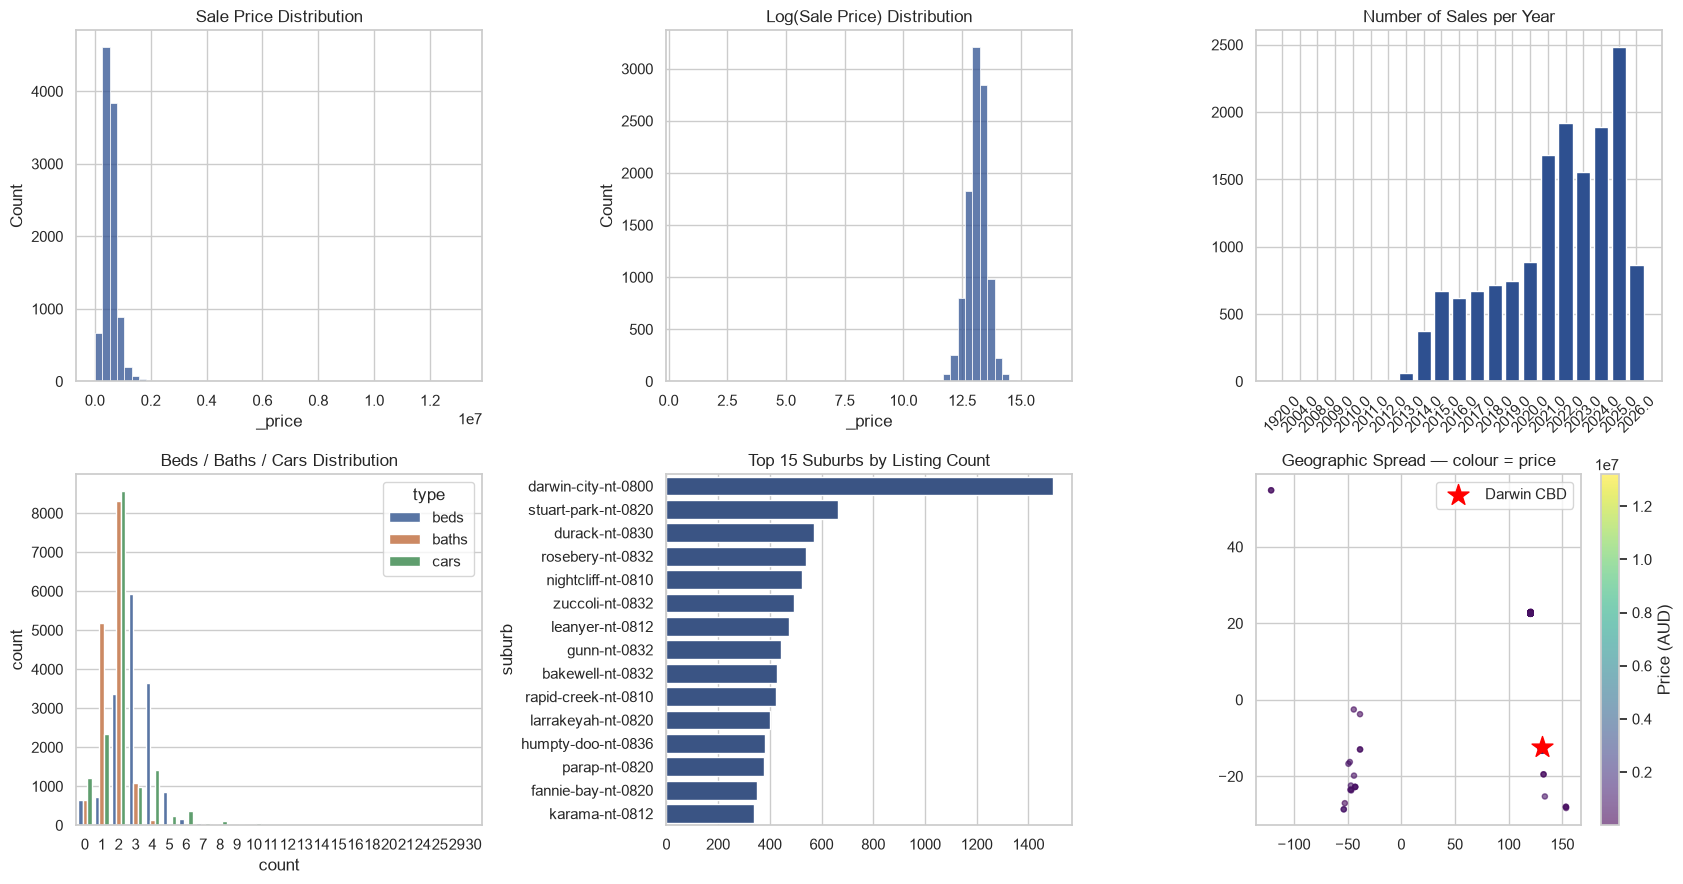

IQR-based price outliers: 337 (3.3%)

ANNUAL HOUSEHOLD INCOME (NT) — RAW
  → INSIGHT [RAW]: Annual household dataset has no parsed 'year' column yet — parse the 'Jun-YYYY' style period labels before using this data. (Which indicators matter can't be determined before that parsing anyway.)

ERP — GREATER DARWIN REGION — RAW
Year coverage: 2006–2026 (21 years)


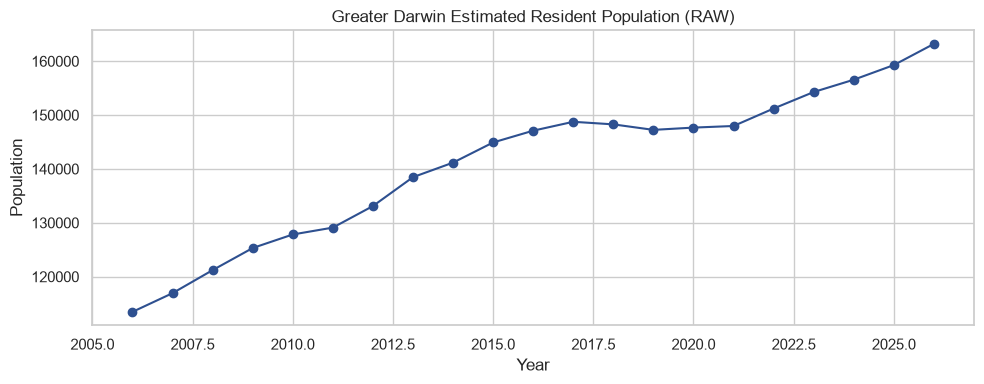

In [808]:
_ = run_full_eda(properties_processed, annual_household_raw, erp_raw, stage="RAW")



## 3. Data Cleaning

### 3.1 Properties Dataset

**Important information from the data (confirmed by the RAW EDA pass above):**

- `suburb` is a **URL slug**, e.g. `"anula-nt-0812"` — not a clean name.
- `land_area_m2` is **text with a unit suffix**, e.g. `"985m²"`.
- `price_undisclosed` is the **string** `"false"`/`"true"`, not `0`/`1`.
- `price_numeric` can be missing even when `price_text` (e.g. `"$540,000"`) is present.

Steps below: parse the suburb slug (into suburb/state/postcode), coerce price/land-area to
numeric, drop/flag undisclosed prices, remove duplicates, and treat outliers using an IQR
filter.

In [809]:
def parse_suburb_slug(slug):
    """Turns a URL slug like 'coconut-grove-nt-0810' into (suburb, state, postcode)."""
    if pd.isna(slug):
        return pd.Series([np.nan, np.nan, np.nan])
    parts = str(slug).strip().lower().split("-")
    postcode, state = np.nan, np.nan
    if parts and parts[-1].isdigit():
        postcode, parts = parts[-1], parts[:-1]
    if parts and parts[-1].isalpha() and len(parts[-1]) <= 3:
        state, parts = parts[-1].upper(), parts[:-1]
    suburb = " ".join(p.capitalize() for p in parts) if parts else np.nan
    return pd.Series([suburb, state, postcode])


def parse_land_area(value):
    if pd.isna(value):
        return np.nan
    digits = re.sub(r"[^0-9.]", "", str(value))
    return float(digits) if digits else np.nan


def parse_bool_ish(value):
    if isinstance(value, bool):
        return int(value)
    s = str(value).strip().lower()
    if s in ("true", "1", "yes"):
        return 1
    if s in ("false", "0", "no", "nan", ""):
        return 0
    return 0


properties = properties_processed.copy()

properties["suburb_raw"] = properties["suburb"]
properties[["suburb", "state", "postcode"]] = properties["suburb_raw"].apply(parse_suburb_slug)
print("Example suburb parsing:")
print(properties[["suburb_raw", "suburb", "state", "postcode"]].drop_duplicates().head(8).to_string(index=False))

properties["sold_date_iso"] = pd.to_datetime(properties["sold_date_iso"], errors="coerce")

if "land_area_m2" in properties.columns:
    properties["land_area_m2"] = properties["land_area_m2"].apply(parse_land_area)

if "price_undisclosed" in properties.columns:
    properties["price_undisclosed"] = properties["price_undisclosed"].apply(parse_bool_ish)
else:
    properties["price_undisclosed"] = 0

properties["price_numeric"] = pd.to_numeric(properties["price_numeric"], errors="coerce")
if "price_text" in properties.columns:
    needs_fallback = properties["price_numeric"].isna() & properties["price_text"].notna()
    fallback_prices = properties.loc[needs_fallback, "price_text"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    properties.loc[needs_fallback, "price_numeric"] = pd.to_numeric(fallback_prices, errors="coerce")
    print(f"Recovered {needs_fallback.sum()} prices from price_text via fallback parsing.")

n_before = len(properties)
properties = properties[(properties["price_undisclosed"] == 0) & properties["price_numeric"].notna()].copy()
print(f"Dropped {n_before - len(properties)} rows with undisclosed/missing price ({len(properties)} remain).")

n_before = len(properties)
properties = properties.drop_duplicates(subset=["property_id"])
print(f"Removed {n_before - len(properties)} duplicate records ({len(properties)} remain).")

n_before = len(properties)
properties = properties.dropna(subset=["latitude", "longitude", "sold_date_iso"])
print(f"Dropped {n_before - len(properties)} rows missing coordinates/sale date ({len(properties)} remain).")

# --- IQR outlier filtering without touching the null values ---
def iqr_filter(df, col, k=1.5):
    valid = df[col].notna()
    q1, q3 = df.loc[valid, col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = ~valid | df[col].between(q1 - k * iqr, q3 + k * iqr)
    return df[mask], (~mask).sum()

properties = properties[properties["sold_date_iso"].dt.year.between(2001, 2026)]
n_before = len(properties)
properties, n_out_price = iqr_filter(properties, "price_numeric")
properties, n_out_land = iqr_filter(properties, "land_area_m2")
print(f"IQR outlier filtering removed {n_out_price} price outliers and {n_out_land} land-area outliers ({len(properties)} remain).")

print(f"\nFinal cleaned properties dataset: {len(properties):,} rows.")
properties.to_csv(PROCESSED_DIR / "properties_clean.csv", index=False)


Example suburb parsing:
           suburb_raw        suburb state postcode
        anula-nt-0812         Anula    NT     0812
      bayview-nt-0820       Bayview    NT     0820
coconut-grove-nt-0810 Coconut Grove    NT     0810
  darwin-city-nt-0800   Darwin City    NT     0800
   fannie-bay-nt-0820    Fannie Bay    NT     0820
      jingili-nt-0810       Jingili    NT     0810
       karama-nt-0812        Karama    NT     0812
   larrakeyah-nt-0820    Larrakeyah    NT     0820
Recovered 0 prices from price_text via fallback parsing.
Dropped 5088 rows with undisclosed/missing price (10335 remain).
Removed 0 duplicate records (10335 remain).
Dropped 126 rows missing coordinates/sale date (10209 remain).
IQR outlier filtering removed 363 price outliers and 913 land-area outliers (8932 remain).

Final cleaned properties dataset: 8,932 rows.


### 3.2 Annual Household Income Dataset (NT, Time Series)

**Important information from the RAW EDA pass above:**

- The file includes several **metadata rows** at the top (`Unit`, `Series Type`, `Data Type`,
  `Frequency`, `Collection Month`, `Series Start`, `Series End`, `No. Obs`, `Series ID`) before
  the actual annual data begins. You mentioned you'll delete these yourself before upload — the
  cleaning step below also filters for valid `Mon-YYYY` rows defensively, in case a metadata row
  slips through.
- The period column (e.g. `"Jun-1990"`) needs to be parsed into a plain integer `year`.
- Column names have a trailing `" ;"` and inconsistent casing/punctuation — cleaned into
  snake_case for consistency with the rest of the pipeline.
- This dataset is **NT-wide**, not suburb-level — it merges into `properties` on `year` only, no
  suburb key required.

In [810]:
def clean_column_name(col):
    col = col.strip().rstrip(";").strip()
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col).strip("_").lower()
    return col

annual_household = annual_household_raw.copy()
annual_household = annual_household.rename(columns={annual_household.columns[0]: "period"})

# Defensive filter: keep only rows that look like "Mon-YYYY" (drops any metadata rows)
valid_period = annual_household["period"].astype(str).str.match(r"^[A-Za-z]{3}-\d{4}$")
n_dropped = (~valid_period).sum()
if n_dropped:
    print(f"Dropped {n_dropped} non-data (metadata) row(s): "
          f"{annual_household.loc[~valid_period, 'period'].tolist()}")
annual_household = annual_household[valid_period].copy()

# Parse "Jun-1990" -> 1990 (financial year label treated as the reference year for joining)
annual_household["year"] = pd.to_datetime(annual_household["period"], format="%b-%Y").dt.year
annual_household = annual_household.drop(columns=["period"])

# Clean column names into snake_case; de-duplicate the two distinct "Other secondary income" columns
new_names = {}
seen_other_secondary = 0
for col in annual_household.columns:
    if col == "year":
        continue
    clean = clean_column_name(col)
    if clean == "other_secondary_income":
        seen_other_secondary += 1
        clean = "other_secondary_income_receivable" if seen_other_secondary == 1 else "other_secondary_income_payable"
    new_names[col] = clean
annual_household = annual_household.rename(columns=new_names)

# Coerce every indicator column to numeric
for col in annual_household.columns:
    if col != "year":
        annual_household[col] = pd.to_numeric(annual_household[col], errors="coerce")

print(f"Cleaned annual_household: {annual_household.shape[0]} years x {annual_household.shape[1]} columns")
print(f"Year range: {annual_household['year'].min()}\u2013{annual_household['year'].max()}")
annual_household.to_csv(PROCESSED_DIR / "annual_household_clean.csv", index=False)
annual_household.tail()


Dropped 9 non-data (metadata) row(s): ['Unit', 'Series Type', 'Data Type', 'Frequency', 'Collection Month', 'Series Start', 'Series End', 'No. Obs', 'Series ID']
Cleaned annual_household: 36 years x 28 columns
Year range: 1990–2025


,gross_operating_surplus_dwellings_owned_by_persons,gross_mixed_income,compensation_of_employees,total_property_income_receivable,total_primary_income_receivable,secondary_income_receivable_social_benefits_receivable_workers_compensation,secondary_income_receivable_social_benefits_receivable_social_assistance_benefits,secondary_income_receivable_current_transfers_to_non_profit_institutions,other_secondary_income_receivable,total_secondary_income_receivable,total_gross_income,property_income_payable_interest_dwellings,property_income_payable_interest_consumer_debt,property_income_payable_unincorporated_enterprises,total_property_income_payable,total_primary_income_payable,secondary_income_payable_income_tax,secondary_income_payable_social_contributions_for_workers_compensation,secondary_income_payable_other_current_taxes_on_income_wealth_etc,other_secondary_income_1,total_secondary_income_payable,total_income_payable,gross_disposable_income,final_consumption_expenditure,net_saving_plus_consumption_of_fixed_capital,total_gross_income_per_capita,gross_household_disposable_income_per_capita,year
40,2577,2046,11624,1880,18126,70,1560,211,512,2353,20479,348,76,33,457,457,2035,69,37,588,2729,3186,17293,11263,6030,82635,69780,2021
41,2855,2279,12362,2177,19673,82,1526,261,554,2423,22096,326,67,35,429,429,2175,86,37,647,2945,3374,18722,12142,6580,88206,74738,2022
42,3147,2294,12984,2433,20857,90,1442,311,532,2376,23233,594,77,68,740,740,2486,100,39,691,3316,4055,19178,13319,5859,91006,75121,2023
43,3349,2289,13862,2570,22069,97,1573,321,630,2621,24690,765,95,82,942,942,2759,108,40,720,3626,4568,20122,14237,5886,95307,77673,2024
44,3441,2598,15080,2733,23853,106,1675,295,668,2744,26597,786,99,132,1017,1017,2820,117,46,764,3746,4763,21833,14975,6858,101440,83273,2025


### 3.3 ERP Dataset (Greater Darwin Region)
`ERP.csv` stores one row per year (2006–2026) with the Greater Darwin Estimated Resident
Population. The `Number` column is text with thousands-separator commas (e.g. `"1,63,219"`) —
stripped and converted to numeric here. There is no suburb dimension to standardise or reshape;
this is already a tidy year-indexed series, ready to merge on `year` alone.


In [811]:
erp = erp_raw.copy()
erp = erp.rename(columns={"Year": "year", "Number": "population"})
erp["population"] = pd.to_numeric(erp["population"].astype(str).str.replace(",", "", regex=False), errors="coerce")
erp["year"] = pd.to_numeric(erp["year"], errors="coerce").astype(int)
erp = erp.sort_values("year").reset_index(drop=True)
erp.to_csv(PROCESSED_DIR / "erp_clean.csv", index=False)
erp.head()



,year,population
0,2006,113461
1,2007,116935
2,2008,121210
3,2009,125315
4,2010,127829


## 3.4 Run EDA — Pass 2: Data After Cleaning

Same functions, run again on the cleaned data. Compare this against the Pass 1 output above:
the suburb-slug/land-area warnings should be gone, and the annual household dataset should now
show a clean, gap-free 1990–2025 range with real trend lines instead of a "single snapshot"
warning.


######################################################################
# FULL EDA PASS — STAGE: CLEANED
######################################################################
  → INSIGHT [CLEANED]: 'agency_name' in properties is 80% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [CLEANED]: 'agent_name' in properties is 80% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [CLEANED]: 'land_area_m2' in properties is 41% missing — decide: impute, drop column, or drop rows.


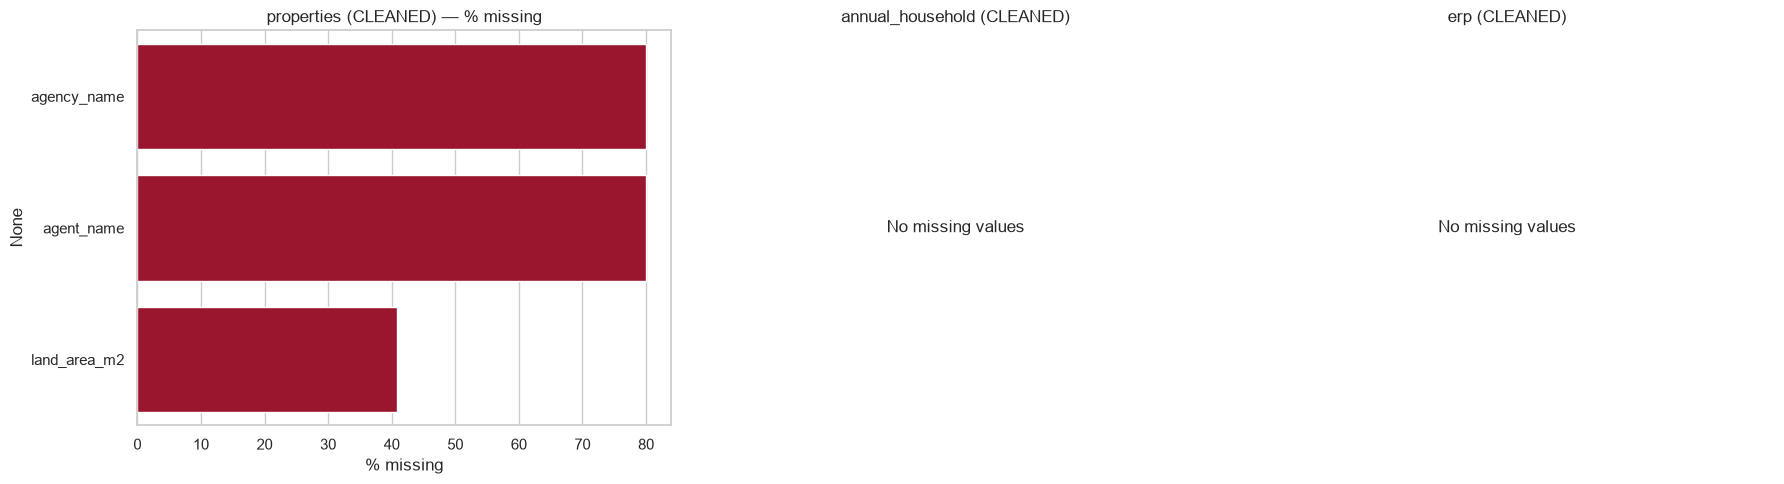


PROPERTIES — CLEANED
Rows: 8,932 | Unique suburbs: 66 | Sale years: 2012–2026


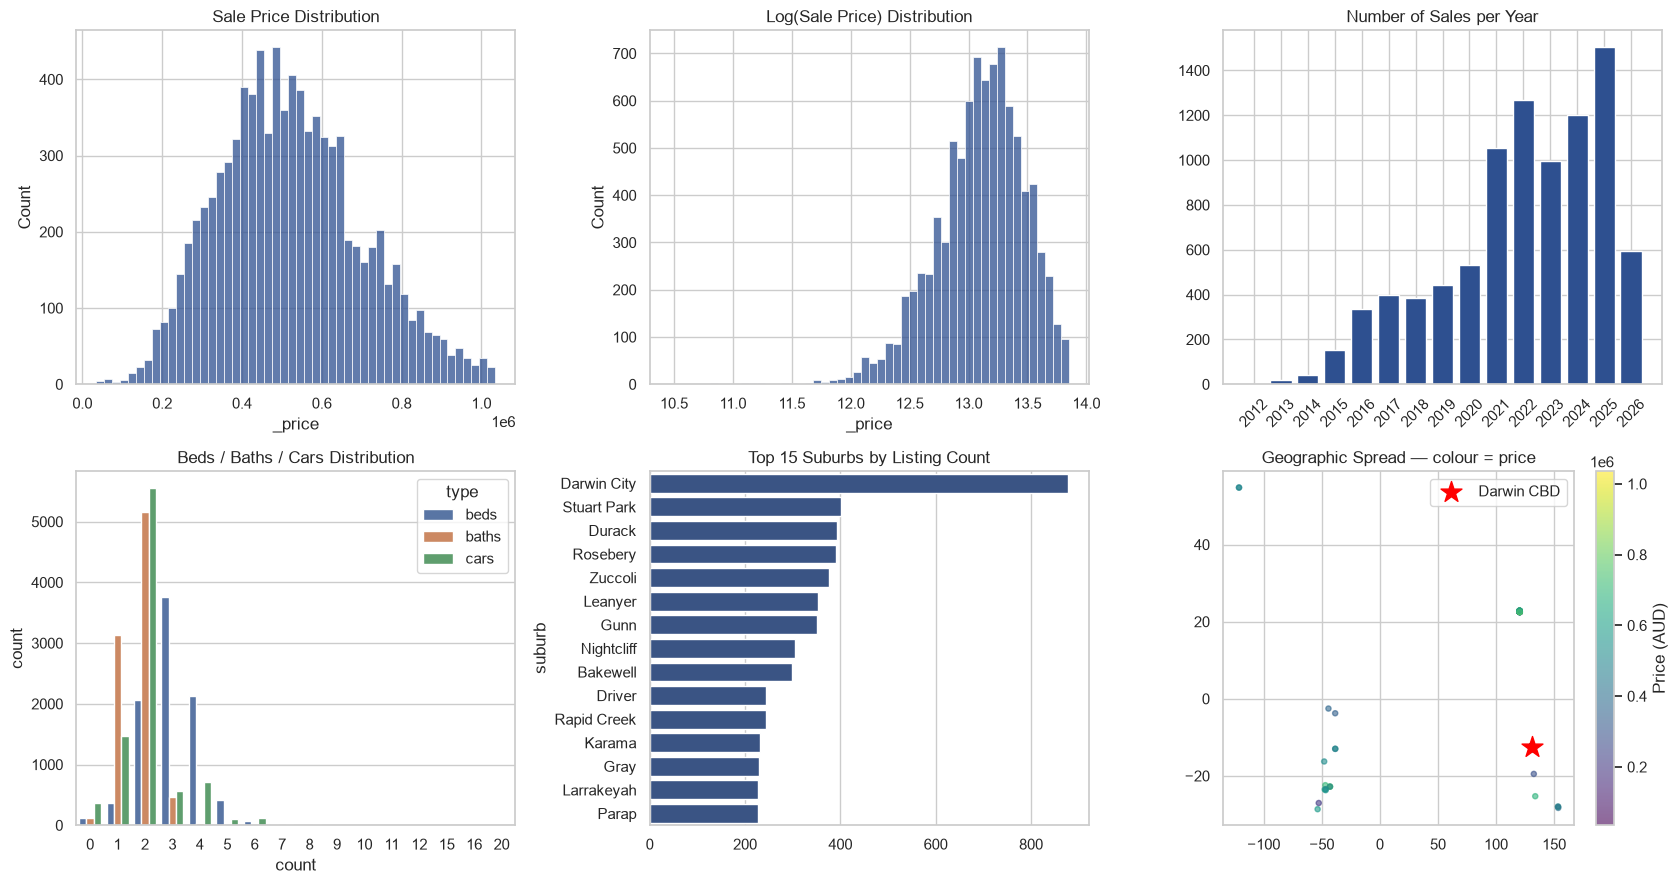

IQR-based price outliers: 58 (0.6%)

ANNUAL HOUSEHOLD INCOME (NT) — CLEANED
Year coverage: 1990–2025 (36 years)


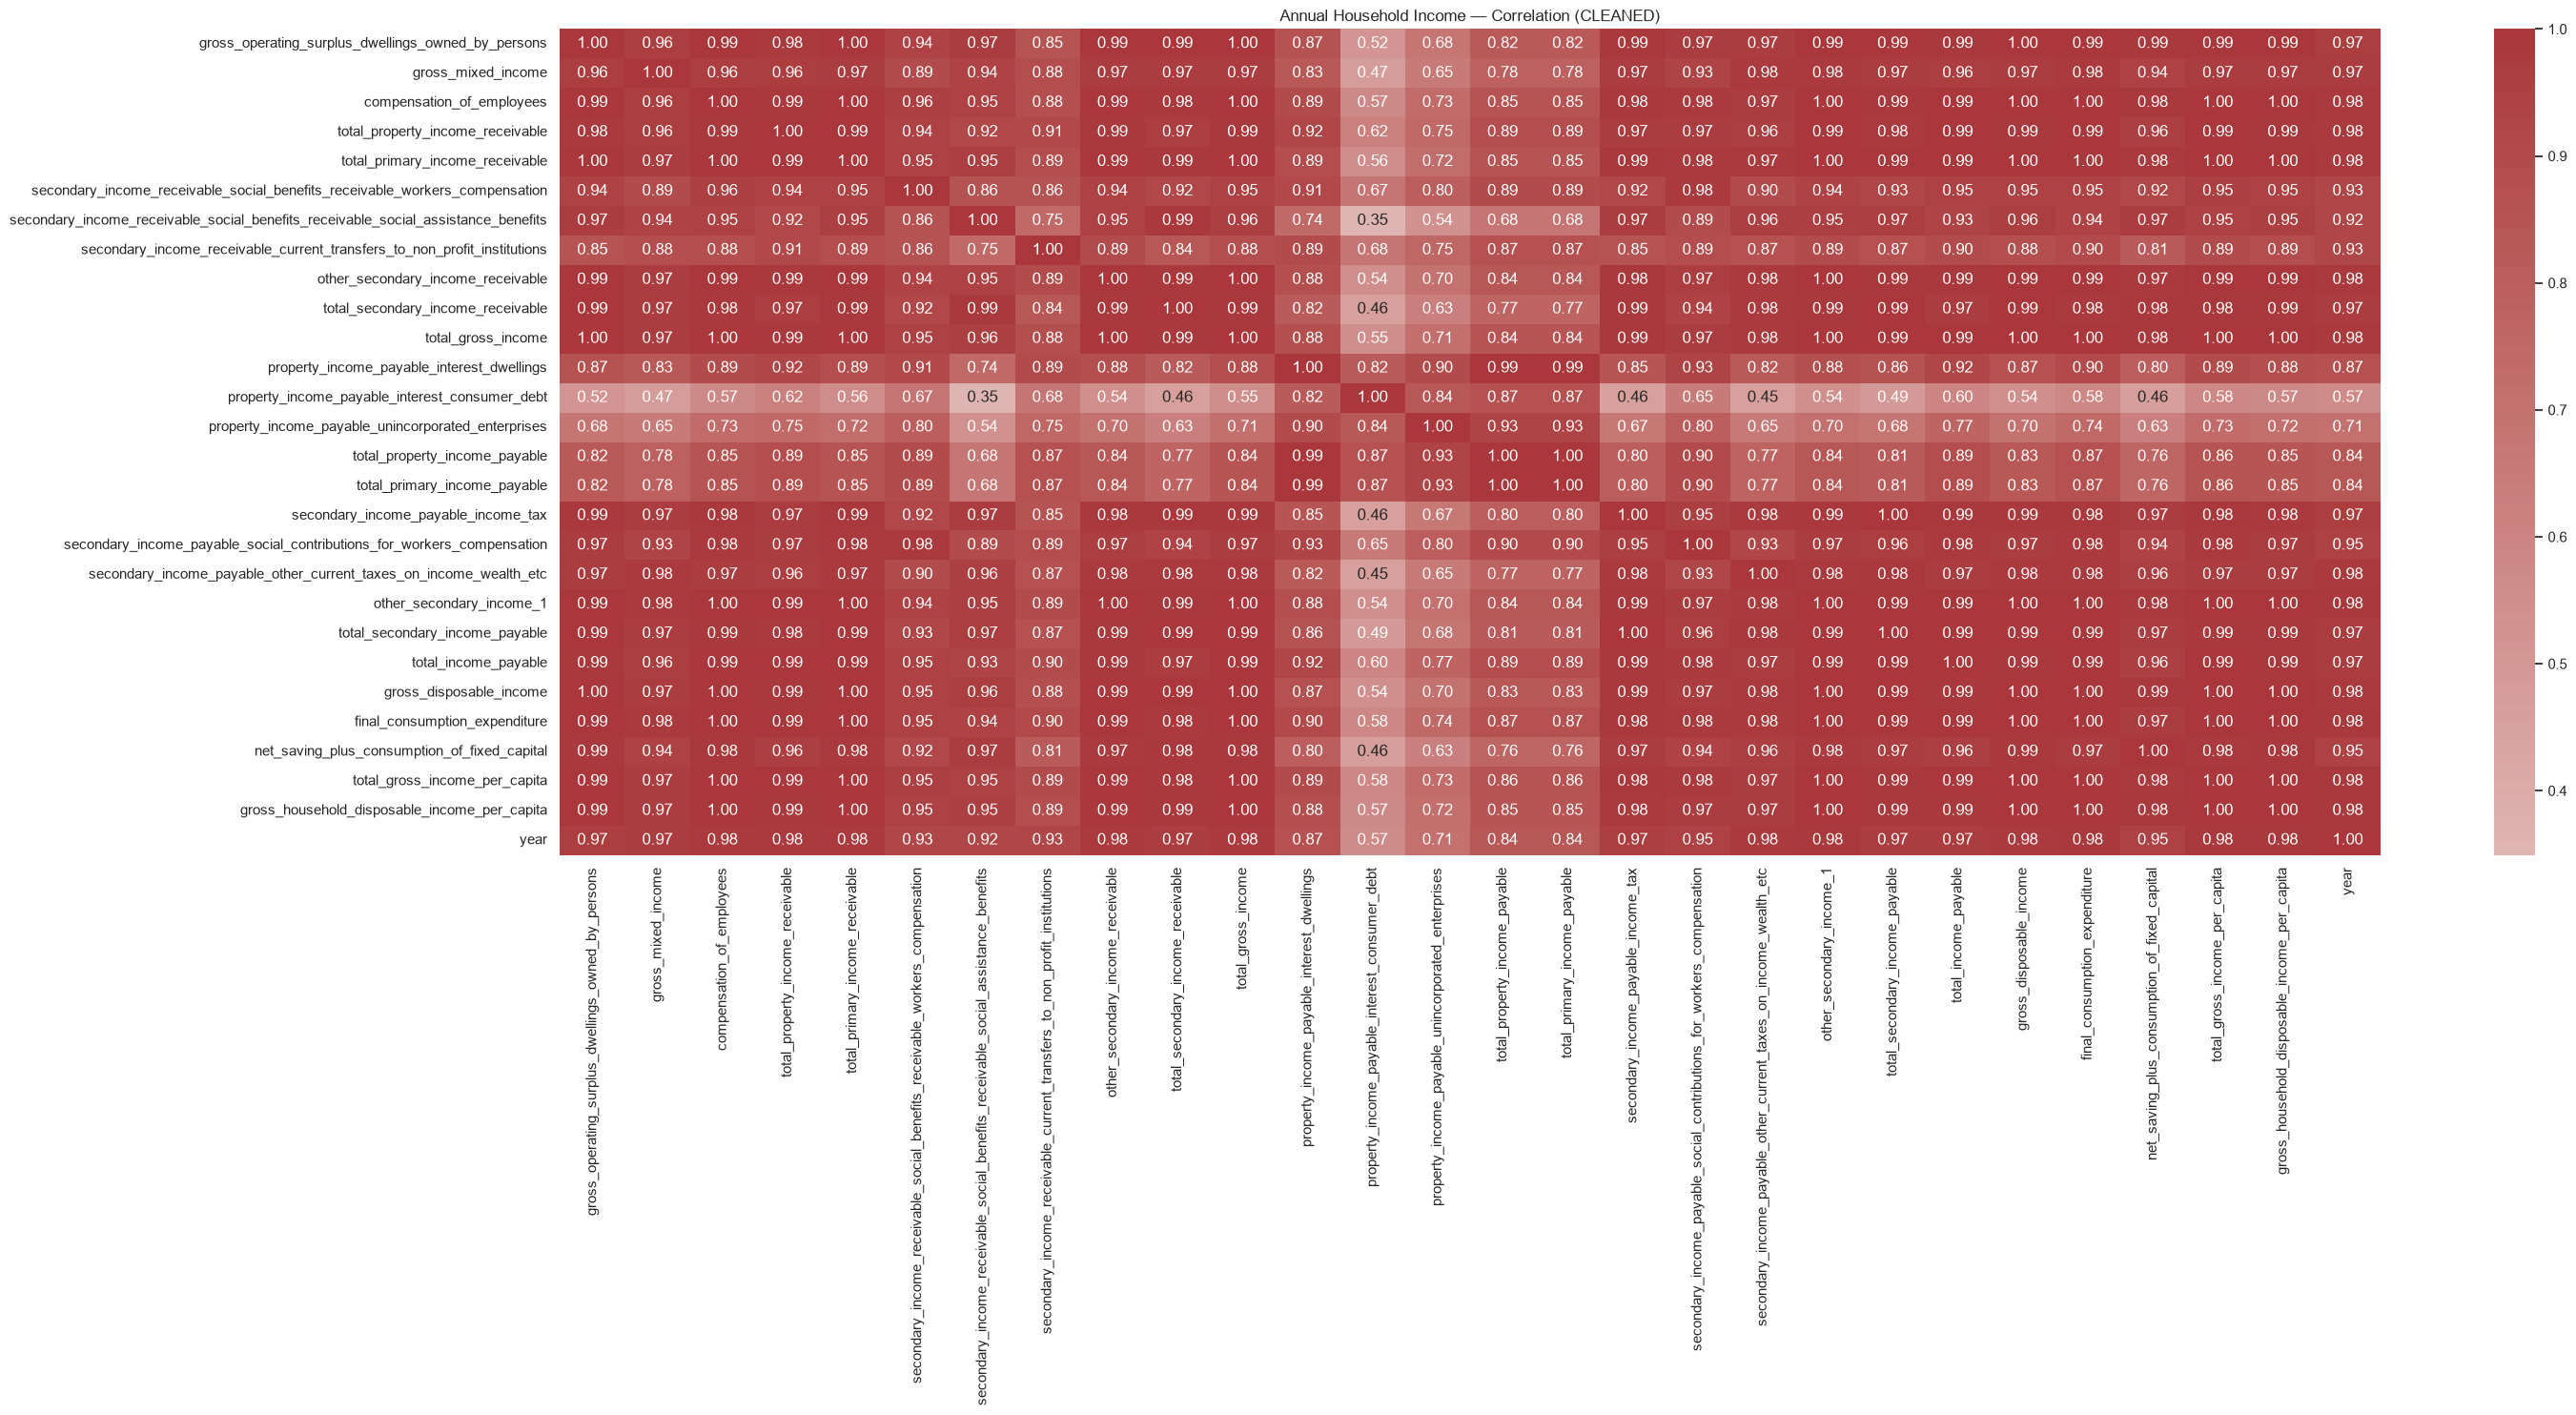

  → INSIGHT [CLEANED]: This dataset is NT-WIDE, not suburb-level — every suburb receives the same figure for a given year. This trades away suburb-level income granularity in exchange for full 1990–2025 year coverage.

ERP — GREATER DARWIN REGION — CLEANED
Year coverage: 2006–2026 (21 years)


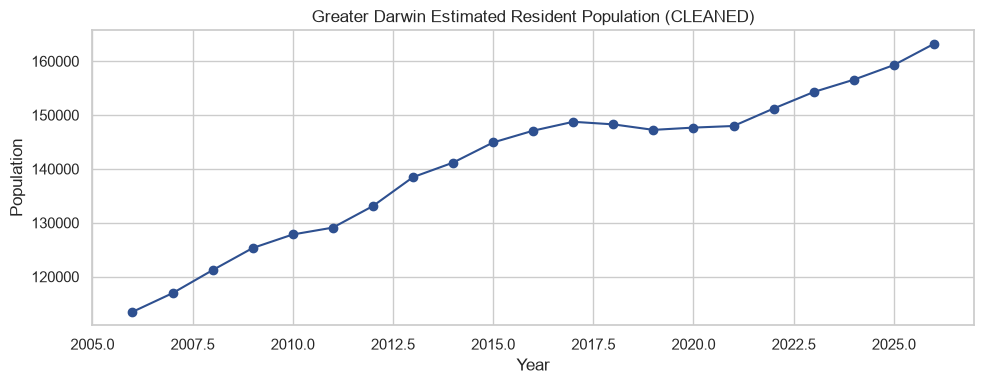

,year,population,_year,_population
0,2006,113461,2006,113461
1,2007,116935,2007,116935
2,2008,121210,2008,121210
3,2009,125315,2009,125315
4,2010,127829,2010,127829
5,2011,129106,2011,129106
6,2012,133105,2012,133105
7,2013,138471,2013,138471
8,2014,141169,2014,141169
9,2015,144914,2015,144914


In [812]:
run_full_eda(properties, annual_household, erp, stage="CLEANED")

## 4. Feature Engineering

### 4.1 Distance from Darwin CBD

In [813]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

properties["distance_from_cbd_km"] = haversine_km(
    properties["latitude"], properties["longitude"], DARWIN_CBD_LAT, DARWIN_CBD_LON
)


### 4.2 Exact year from the date

In [814]:
properties["sale_year"] = properties["sold_date_iso"].dt.year
properties["sale_month"] = properties["sold_date_iso"].dt.month

## 5. Merging Datasets

Both remaining datasets now merge on **`year` alone** — no suburb key, no fuzzy/composite
matching. `erp` is the Greater Darwin-wide population estimate, and since every property in
`properties` is located within Greater Darwin, every sale gets the correct population figure for
its sale year regardless of which suburb it's in. Same logic as `annual_household` (NT-wide
economic indicators): one value per year, joined straight onto every property sold that year.


In [815]:
# --- merge ERP (year only -- Greater Darwin-wide, no suburb key needed since every
# property in `properties` is located within Greater Darwin) ---
merged = properties.merge(
    erp.rename(columns={"year": "erp_year", "population": "erp_population"}),
    left_on="sale_year", right_on="erp_year", how="left"
)

# --- merge annual_household (year only -- NT-wide, no suburb key) ---
merged = merged.merge(
    annual_household, left_on="sale_year", right_on="year", how="left", suffixes=("", "_nt")
)

print(f"ERP population match rate: {merged['erp_population'].notna().mean()*100:.1f}% "
      f"(should be ~100% — continuous year-only join, every sale is within Greater Darwin)")
print(f"Annual household match rate: {merged['total_gross_income'].notna().mean()*100:.1f}% "
      f"(should be ~100% since it's a continuous year-only join)")
merged.to_csv(PROCESSED_DIR / "merged_raw.csv", index=False)
print(f"Merged shape: {merged.shape}")



ERP population match rate: 100.0% (should be ~100% — continuous year-only join, every sale is within Greater Darwin)
Annual household match rate: 93.3% (should be ~100% since it's a continuous year-only join)
Merged shape: (8932, 54)


### 5.1 Year-Coverage Check (replaces the old `years_since_census` feature)

Because `annual_household` is a genuine multi-year series rather than a single snapshot, there
is no systematic "future data" leakage to correct for here — every sale year should find a
matching row directly. This just confirms that's actually true rather than assuming it.

In [816]:
unmatched_years = merged.loc[merged["total_gross_income"].isna(), "sale_year"].unique()
if len(unmatched_years):
    note("POST-MERGE", f"Sale year(s) with no annual_household match: {unmatched_years} ")
else:
    print("Every sale year matched the annual household series exactly \u2014 no gap-filling needed.")


  → INSIGHT [POST-MERGE]: Sale year(s) with no annual_household match: [2026] 


### 5.2 Post-Merge Cleaning & Imputation

In [817]:
model_df = merged.dropna(subset=["price_numeric"]).copy()
household_features = [
    "gross_household_disposable_income_per_capita",
    "total_gross_income_per_capita",
    "gross_mixed_income",
    "property_income_payable_interest_dwellings",
    "property_income_payable_interest_consumer_debt",
    "property_income_payable_unincorporated_enterprises",
    "secondary_income_receivable_social_assistance_benefits",
]


numeric_candidates = [
    "beds", "baths", "cars", "land_area_m2", "price_per_sqm", "distance_from_cbd_km",
    "erp_population",
] + household_features
numeric_candidates = [c for c in numeric_candidates if c in model_df.columns]

for col in numeric_candidates:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    if model_df[col].isna().any():
        if col == "land_area_m2":
            land_median_by_beds = (
                model_df
                .groupby("beds", dropna=True)["land_area_m2"]
                .transform("median")
            )

            model_df["land_area_m2"] = (
                model_df["land_area_m2"]
                .fillna(land_median_by_beds)          
                .fillna(model_df["land_area_m2"].median())  # fallback global median if beds is also NaN
            )
        else:
            model_df[col] = model_df[col].fillna(model_df[col].median())
    
    model_df[col] = model_df[col].fillna(model_df[col].median())
print("Numeric features retained for modelling:", numeric_candidates)
print(f"Final model-ready dataset: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")
model_df.to_csv(MODEL_READY_DIR / "model_ready.csv", index=False)



Numeric features retained for modelling: ['beds', 'baths', 'cars', 'land_area_m2', 'distance_from_cbd_km', 'erp_population', 'gross_household_disposable_income_per_capita', 'total_gross_income_per_capita', 'gross_mixed_income', 'property_income_payable_interest_dwellings', 'property_income_payable_interest_consumer_debt', 'property_income_payable_unincorporated_enterprises']
Final model-ready dataset: 8,932 rows x 54 columns


## Feature Engineering Post Imputation

In [818]:
model_df["price_per_sqm"] = model_df["price_numeric"] / model_df["land_area_m2"]
numeric_candidates = numeric_candidates + ["price_per_sqm"]
model_df[["distance_from_cbd_km", "price_per_sqm", "sale_year", "sale_month"]].describe().T

,count,mean,std,min,25%,50%,75%,max
distance_from_cbd_km,8932.0,69.923819,759.658498,0.013135,5.047482,10.906102,15.697521,18262.529709
price_per_sqm,8932.0,1541.979946,7424.652336,35.971223,699.300699,944.153408,1867.270479,430000.000000
sale_year,8932.0,2021.962382,2.923642,2012.000000,2020.000000,2022.000000,2024.000000,2026.000000
sale_month,8932.0,6.649687,3.333359,1.000000,4.000000,7.000000,10.000000,12.000000


## 6. Run EDA — Pass 3: Post-Merge (Correlation With Target)

This third pass is different in kind from the first two: with the target variable
(`price_numeric`) now sitting alongside every engineered/merged feature in one table, this is
the point where EDA can actually tell you **which features are worth keeping** — not just
"is this column clean", but "does this column relate to price at all". Features with
near-zero correlation are candidates to drop or transform; features with strong correlation
justify the modelling choices in Section 8.

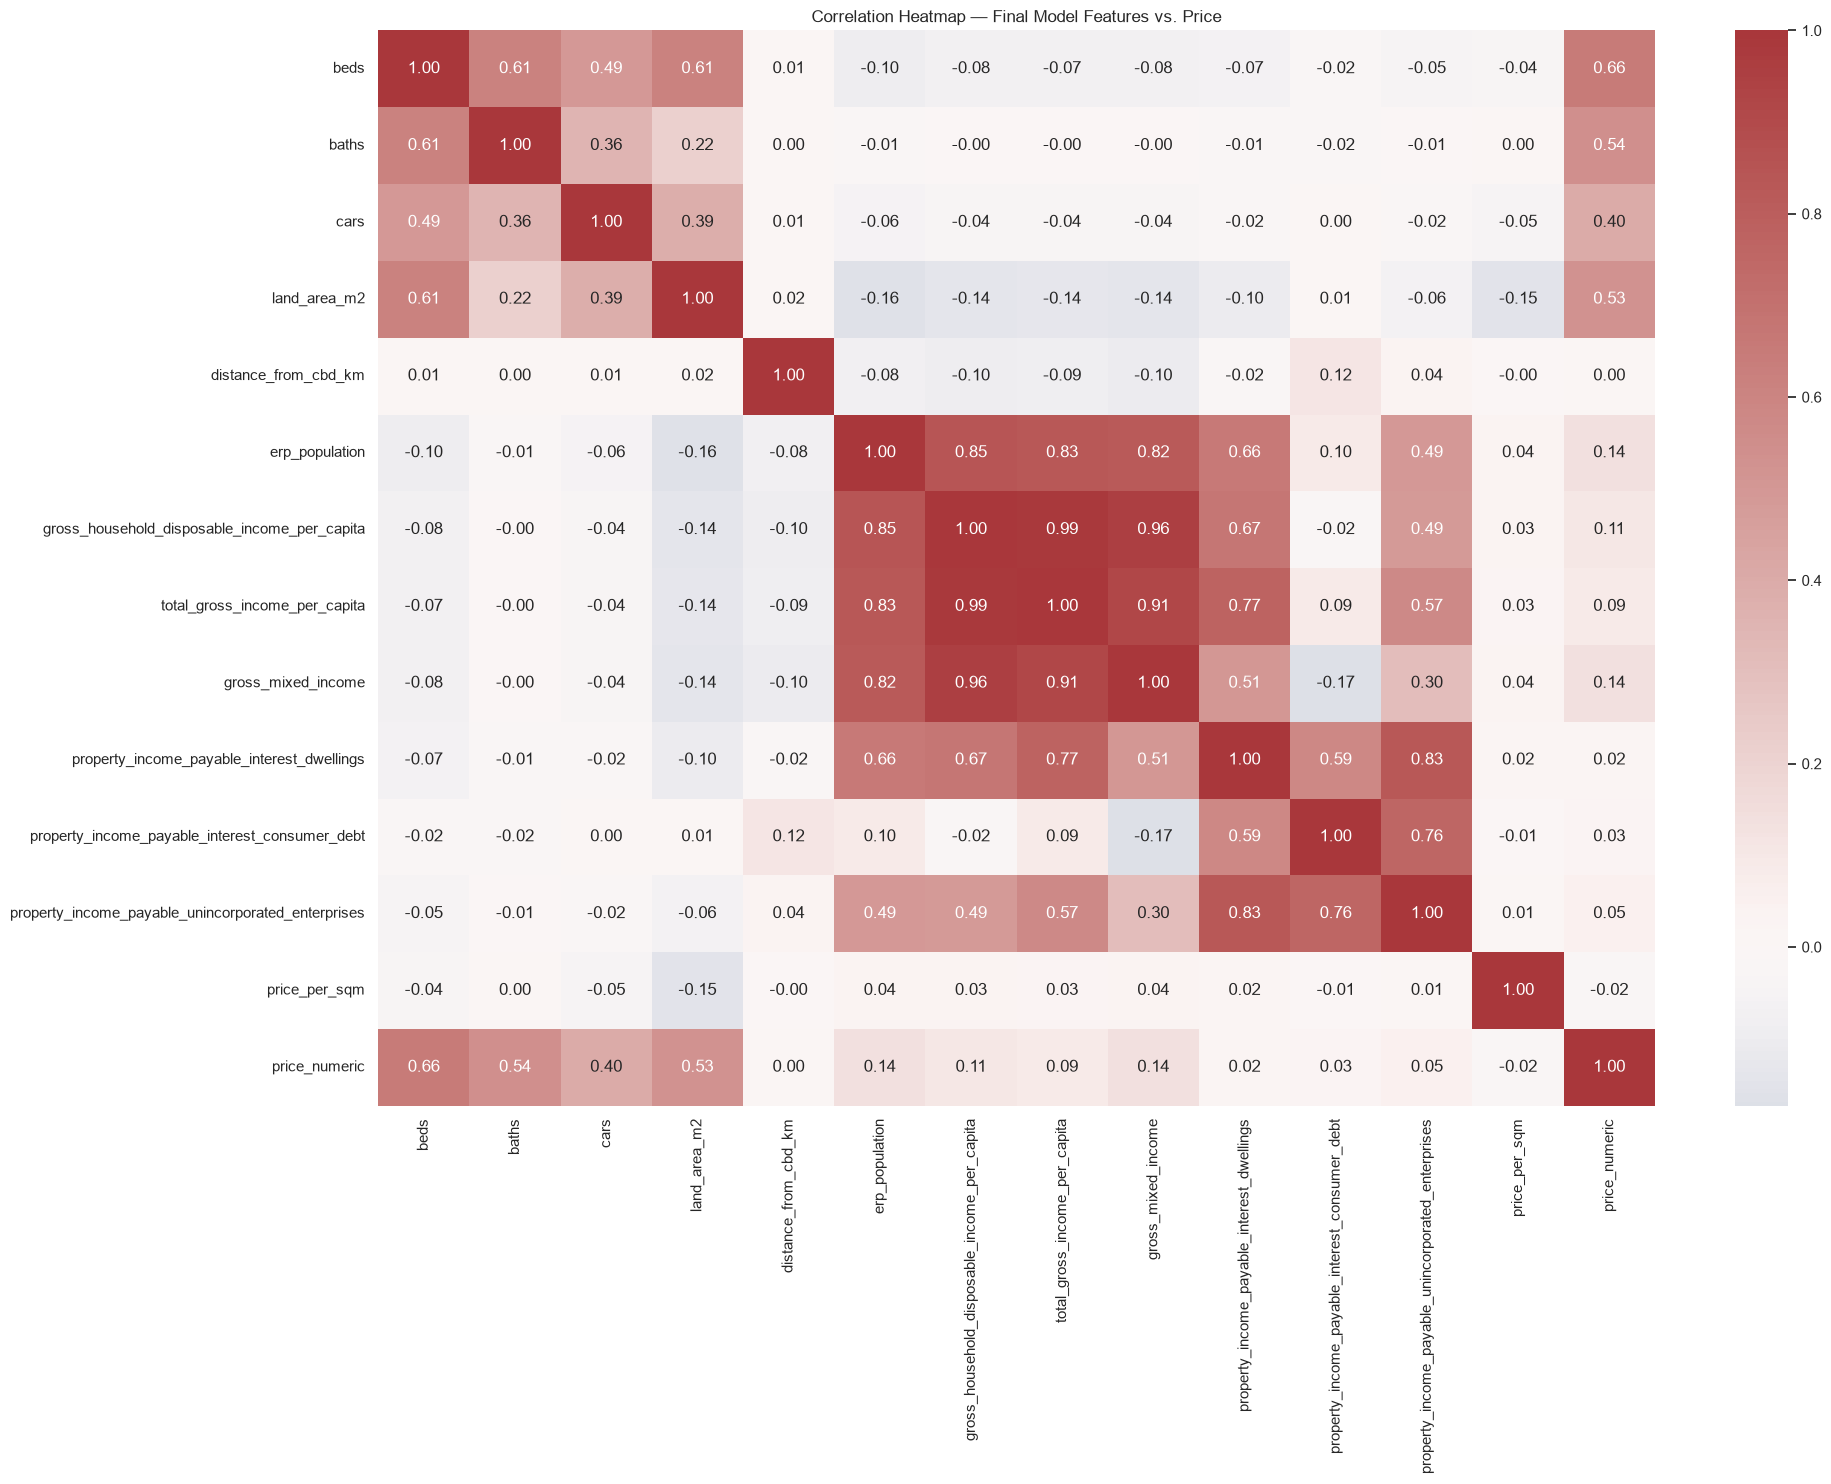

Features ranked by |correlation| with price_numeric:
beds                                                  0.655881
baths                                                 0.544120
land_area_m2                                          0.531037
cars                                                  0.403799
erp_population                                        0.142681
gross_mixed_income                                    0.138885
gross_household_disposable_income_per_capita          0.108827
total_gross_income_per_capita                         0.088124
property_income_payable_unincorporated_enterprises    0.049449
property_income_payable_interest_consumer_debt        0.029627
property_income_payable_interest_dwellings            0.021757
price_per_sqm                                        -0.016141
distance_from_cbd_km                                  0.001471
Name: price_numeric, dtype: float64
  → INSIGHT [POST-MERGE]: 'beds' correlates strongly with price (0.66) — a key driver worth 

In [819]:
corr_cols = numeric_candidates + ["price_numeric"]
corr_matrix = model_df[corr_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap — Final Model Features vs. Price")
plt.tight_layout()
plt.show()

price_corr = corr_matrix["price_numeric"].drop("price_numeric").sort_values(key=abs, ascending=False)
print("Features ranked by |correlation| with price_numeric:")
print(price_corr)

for feat, corr_val in price_corr.items():
    if abs(corr_val) < 0.05:
        note("POST-MERGE", f"'{feat}' has near-zero linear correlation with price ({corr_val:.2f}) "
                            f"— unlikely to help Linear Regression; tree models may still use it "
                            f"via non-linear splits.")
    elif abs(corr_val) > 0.4:
        note("POST-MERGE", f"'{feat}' correlates strongly with price ({corr_val:.2f}) — a key "
                            f"driver worth highlighting in the report.")


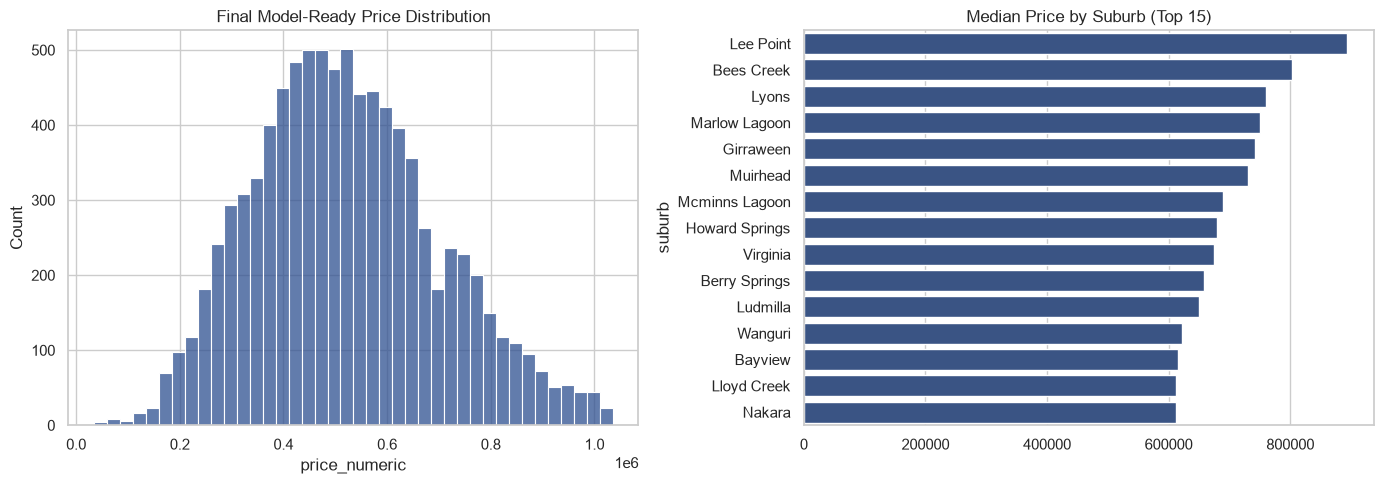

In [820]:
# Target distribution + top suburbs by median price (final, merged view)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(model_df["price_numeric"], bins=40, ax=axes[0], color="#2E5090")
axes[0].set_title("Final Model-Ready Price Distribution")

top_suburbs_price = model_df.groupby("suburb")["price_numeric"].median().sort_values(ascending=False).head(15)
sns.barplot(x=top_suburbs_price.values, y=top_suburbs_price.index, ax=axes[1], color="#2E5090")
axes[1].set_title("Median Price by Suburb (Top 15)")
plt.tight_layout()
plt.show()


## 7. Temporal Train/Test Split

This is a **forecasting** problem, so the split is by time (train on earlier sales, test on the
most recent) rather than random — a random split would let the model "see" pricing patterns
from sales that happened after the ones it's being tested on, which is a form of leakage the
Week 2/3 lectures explicitly warn against.

In [821]:
model_df = model_df.sort_values("sold_date_iso").reset_index(drop=True)
cutoff = model_df["sold_date_iso"].quantile(0.8)
train_df = model_df[model_df["sold_date_iso"] <= cutoff].copy()
test_df = model_df[model_df["sold_date_iso"] > cutoff].copy()

print(f"Temporal cutoff: {cutoff.date()}")
print(f"Train: {len(train_df):,} rows ({train_df['sold_date_iso'].min().date()} to {train_df['sold_date_iso'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['sold_date_iso'].min().date()} to {test_df['sold_date_iso'].max().date()})")


Temporal cutoff: 2025-03-27
Train: 7,150 rows (2012-08-14 to 2025-03-27)
Test:  1,782 rows (2025-03-28 to 2026-08-11)


## 8. Preprocessing Pipeline

In [822]:
TARGET = "price_numeric"
categorical_features = ["suburb"]
feature_cols = numeric_candidates + categorical_features

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_candidates),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


## 9. Model Training & Evaluation — Predicting Actual House Prices

Three models, as specified in Assessment 1: **Linear Regression** (interpretable baseline),
**Random Forest**, and **XGBoost** (both able to capture non-linear relationships that the
correlation heatmap above can't reveal). Evaluated with RMSE, MAE, and R² on the held-out
(temporally later) test set.

In [823]:
def evaluate(name, y_test, preds):
    rmse = math.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return {"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 4)}

results = []
fitted_models = {}
predictions = {}

# --- Linear Regression ---
lr_pipeline = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
lr_pipeline.fit(X_train, y_train)
predictions["Linear Regression"] = lr_pipeline.predict(X_test)
results.append(evaluate("Linear Regression", y_test, predictions["Linear Regression"]))
fitted_models["Linear Regression"] = lr_pipeline

# --- Random Forest ---
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)
predictions["Random Forest"] = rf_pipeline.predict(X_test)
results.append(evaluate("Random Forest", y_test, predictions["Random Forest"]))
fitted_models["Random Forest"] = rf_pipeline

# --- XGBoost ---
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                            random_state=RANDOM_STATE, n_jobs=-1)),
])
xgb_pipeline.fit(X_train, y_train)
predictions["XGBoost"] = xgb_pipeline.predict(X_test)
results.append(evaluate("XGBoost", y_test, predictions["XGBoost"]))
fitted_models["XGBoost"] = xgb_pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df.to_csv(OUTPUT_DIR / "model_evaluation_metrics.csv", index=False)
results_df


,Model,RMSE,MAE,R2
2,XGBoost,22467.13,12668.09,0.9858
1,Random Forest,30971.55,12615.06,0.9729
0,Linear Regression,168455.56,132707.46,0.1989


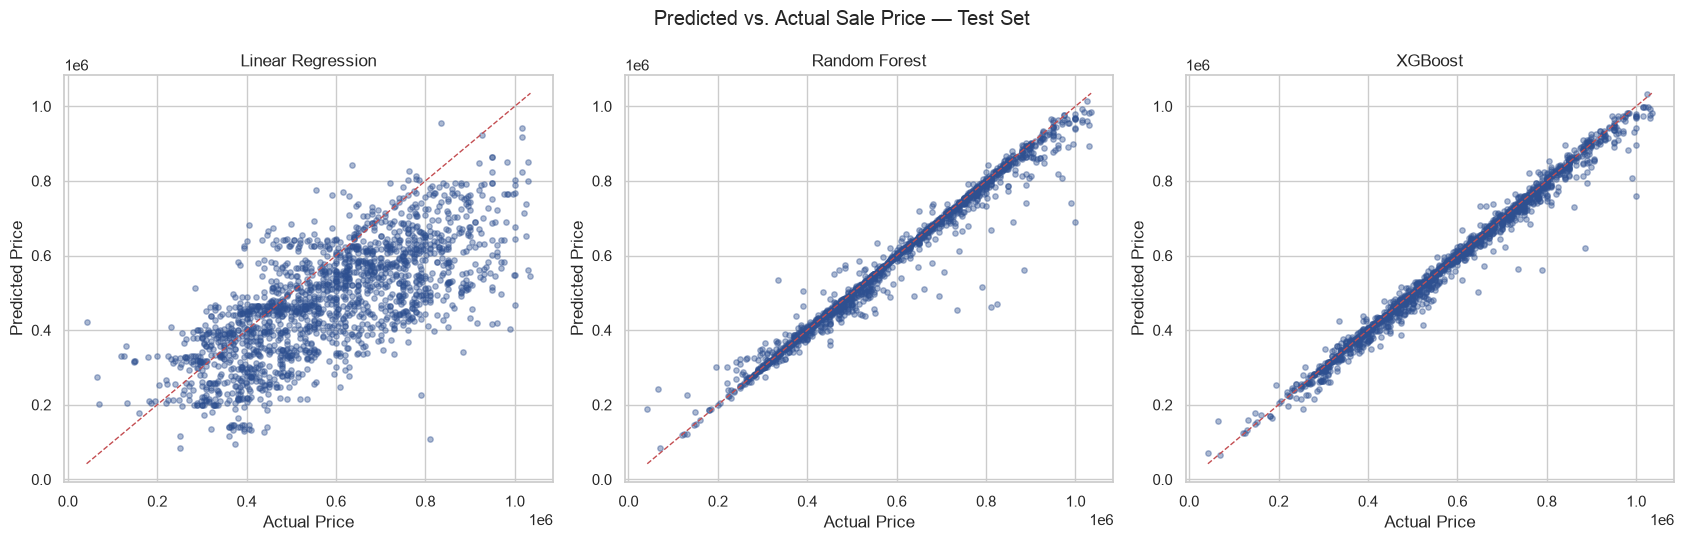

In [824]:
# Predicted vs. Actual price, all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.4, s=15, color="#2E5090")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
plt.suptitle("Predicted vs. Actual Sale Price — Test Set")
plt.tight_layout()
plt.show()


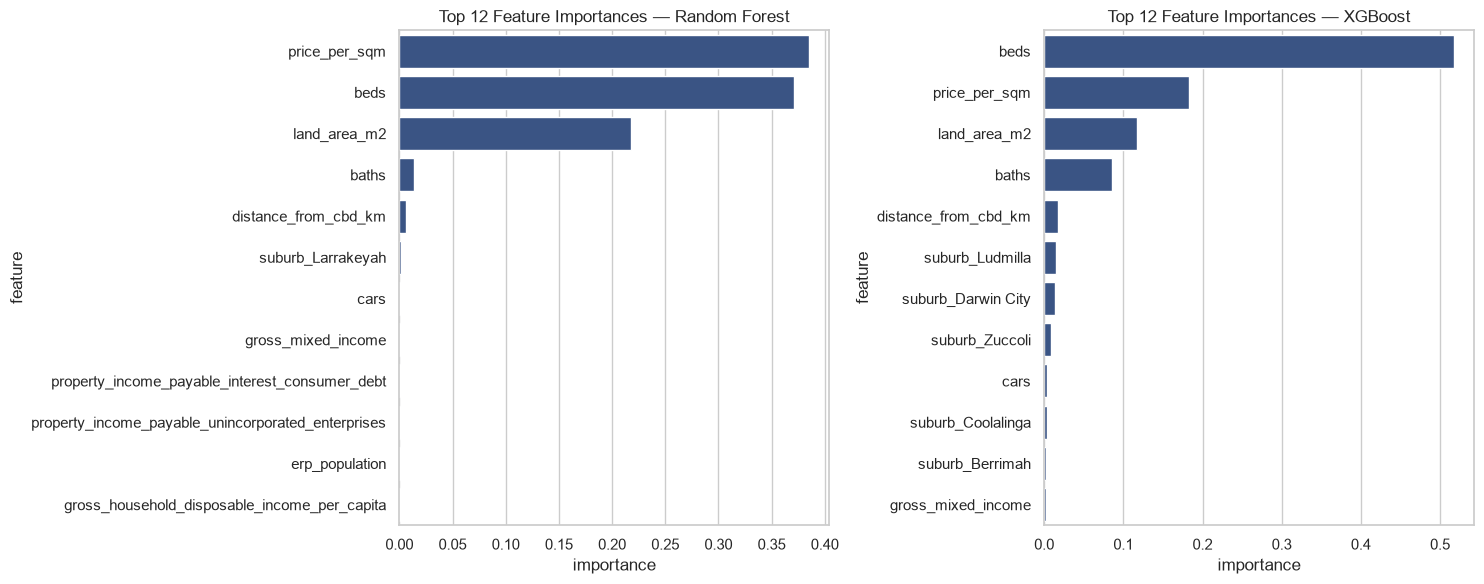

In [825]:
# Feature importance (tree-based models)
def get_feature_names(preprocessor):
    cat_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
    return numeric_candidates + cat_names

feat_names = get_feature_names(fitted_models["XGBoost"].named_steps["prep"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    importances = fitted_models[name].named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(12)
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, color="#2E5090")
    ax.set_title(f"Top 12 Feature Importances — {name}")
plt.tight_layout()
plt.show()


## 10. Export Outputs

In [826]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model on RMSE: {best_model_name}")

test_output = test_df[["property_id", "suburb", "sold_date_iso", "price_numeric"]].copy()
for name, preds in predictions.items():
    test_output[f"predicted_{name.lower().replace(' ', '_')}"] = preds
test_output.to_csv(OUTPUT_DIR / "predictions.csv", index=False)

for name, pipe in fitted_models.items():
    joblib.dump(pipe, OUTPUT_DIR / f"model_{name.lower().replace(' ', '_')}.joblib")

print("Saved to", OUTPUT_DIR)


Best model on RMSE: XGBoost
Saved to ../data/output


## 11. Consolidated Insights — What the EDA Told Us to Do

Every `note()` call from all three EDA passes (RAW → CLEANED → POST-MERGE), in one place. This
is the direct evidence trail from "what we saw in the data" to "what we did about it" — worth
pasting into Assessment 2, Section 3.2 (Veracity) and Section 3.10 (Risk).

In [827]:
print(f"Total insights logged: {len(INSIGHTS)}\n")
for stage, message in INSIGHTS:
    print(f"[{stage}] {message}")


Total insights logged: 22

[RAW] 'agency_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
[RAW] 'agent_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
[RAW] 'land_area_m2' in properties is 38% missing — decide: impute, drop column, or drop rows.
[RAW] 'price_text' in properties is 33% missing — decide: impute, drop column, or drop rows.
[RAW] 'price_numeric' in properties is 33% missing — decide: impute, drop column, or drop rows.
[RAW] suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a clean name before joining with census/population data.
[RAW] land_area_m2 looks like text with unit suffixes (e.g. '985m²') — strip non-numeric characters before treating it as a number.
[RAW] Annual household dataset has no parsed 'year' column yet — parse the 'Jun-YYYY' style period labels before using this data. (Which indicators matter can't be determined before that parsing anyway.)
[CLEANED] 'agency_name' in properties 